In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
client = MongoClient("mongodb://localhost:27017/")

db = client["sample_supplies"]

collection = db["sales"]

print(f"total sales:{collection.count_documents({}):,}")

total sales:5,000


# Q12.How much total sales revenue was generated through each purchase method?

In [4]:
#code for Query 12
from pprint import pprint

pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$purchaseMethod",
            "totalRevenue": { "$sum": {
                    "$multiply": [{"$toDouble":"$items.price"}, "$items.quantity"]} }
        }
    },
    {
        "$sort": {"totalRevenue": -1}
    }
]

total = list(collection.aggregate(pipeline))

total_df = pd.DataFrame(total)

total_df.rename(columns={"_id": "purchaseMethod"}, inplace=True)

total_df



,purchaseMethod,totalRevenue
0,In store,5619138.67
1,Online,3163814.67
2,Phone,1111618.93


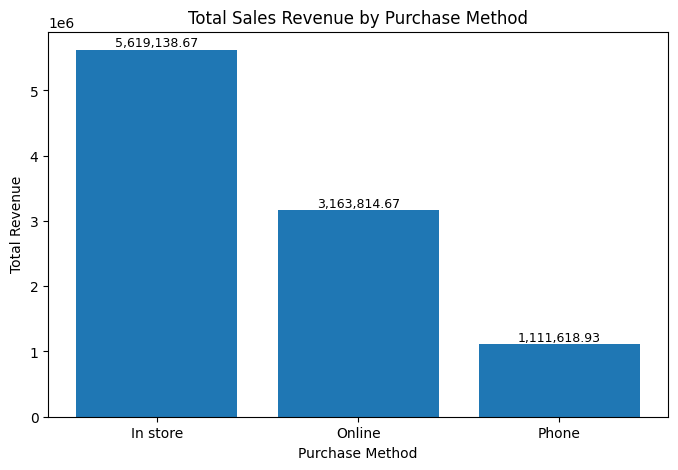

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(total_df["purchaseMethod"], total_df["totalRevenue"])

plt.title("Total Sales Revenue by Purchase Method")
plt.xlabel("Purchase Method")
plt.ylabel("Total Revenue")

# Display values on top of bars
for i, value in enumerate(total_df["totalRevenue"]):
    plt.text(i, value + 50000, f"{value:,.2f}", ha='center', fontsize=9)

plt.show()